In [3]:
#pip install duckdb

In [3]:
#import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Instalar la librería gdown si es necesario
#!pip install --upgrade gdown

# import gdown
# import os

# # 2. Configuración del ID del archivo y la URL de descarga
# FILE_ID = '1kDasOXgXimvPn2Shu3wgZymbqj4_8pDc'  
# url = f'https://drive.google.com/uc?id={FILE_ID}'
# output_file = '2019-Oct.csv'

# # 3. Descargar el archivo solo si no existe localmente (para evitar descargas repetidas)
# if not os.path.exists(output_file):
#     print("Iniciando la descarga del dataset de 5GB desde Google Drive...")
#     # gdown se encarga de gestionar la advertencia de tamaño de Google
#     gdown.download(url, output_file, quiet=False)
#     print("¡Descarga completada!")
# else:
#     print("El archivo ya existe en el entorno local.")

Dado el problema de los eventos raros (pocas compras, muchas vistas), lo ideal es no es hacer una muestra 100% aleatoria de todo, sino un muestreo estratificado: traer *TODAS* las compras (para no perder ni un solo dato de ventas) y una muestra del 2% de las vistas (porque todas las vistas se comportan de manera similar).

In [ ]:
# con = duckdb.connect()

# # Query para traer:
# # 1. El 100% de los eventos 'purchase' y 'cart'
# # 2. Solo un 2% de los eventos 'view' para no saturar la memoria
# query = """
#     SELECT * FROM read_csv_auto('2019-Oct.csv') 
#     USING SAMPLE 500000;
# """

# # Ejecutamos y guardamos en un DataFrame de Pandas
# df_muestra = con.execute(query).df()

# print(f"Tamaño de la muestra: {len(df_muestra)} filas")
# print(df_muestra['event_type'].value_counts())

Tamaño de la muestra: 500000 filas
event_type
view        480542
cart         10851
purchase      8607
Name: count, dtype: int64


Este fue el resultado de hacer un muestrero aleatorio de 500000 registros de la base de datos 2019-Oct.csv

- Tamaño de la muestra: 500000 filas
event_type
- view        480542
- cart         10851
- purchase      8607
- Name: count, dtype: int64

In [17]:
#df_muestra.to_csv('muestra_eventos.csv', index=False)

In [5]:
df_muestra = pd.read_csv("./raw/muestra_eventos_def.csv")
print(df_muestra.shape)
df_muestra.head()

(500000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-16 14:47:46,view,25600036,2053013559675191951,NaN,mart,270.25,520700334,cf4b59d7-51ce-4235-bff1-2e023521d038
1,2019-10-31 11:06:12,view,1005115,2053013555631882655,electronics.smartphone,apple,952.37,529546123,1c0ab992-d849-4cfb-9c52-44ee750ebe6e
2,2019-10-24 10:33:09,view,1004227,2053013555631882655,electronics.smartphone,apple,1002.57,546385140,e5953cd4-124a-4341-b3e4-95c7933f42cc
3,2019-10-11 10:14:00,view,23300386,2053013561956893455,NaN,arua,30.86,551689123,a21706f9-7631-4ff0-a7d1-eee00d45acf6
4,2019-10-20 09:07:45,view,1005014,2053013555631882655,electronics.smartphone,samsung,544.38,558151232,47c24ba5-1cb4-4d4e-bb80-42ab2006ae6b


## Inspección básica del dataset

In [19]:
print(df_muestra.info())

print("\nColumns:")
print(df_muestra.columns)

print("\nData Types:")
print(df_muestra.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   event_time     500000 non-null  datetime64[us]
 1   event_type     500000 non-null  object        
 2   product_id     500000 non-null  int64         
 3   category_id    500000 non-null  int64         
 4   category_code  341012 non-null  object        
 5   brand          427967 non-null  object        
 6   price          500000 non-null  float64       
 7   user_id        500000 non-null  int64         
 8   user_session   500000 non-null  object        
dtypes: datetime64[us](1), float64(1), int64(3), object(4)
memory usage: 34.3+ MB
None

Columns:
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

Data Types:
event_time       datetime64[us]
event_type          

               Missing Values  Missing Percentage
category_code          158988             31.7976
brand                   72033             14.4066
event_time                  0              0.0000
product_id                  0              0.0000
event_type                  0              0.0000
category_id                 0              0.0000
price                       0              0.0000
user_id                     0              0.0000
user_session                0              0.0000


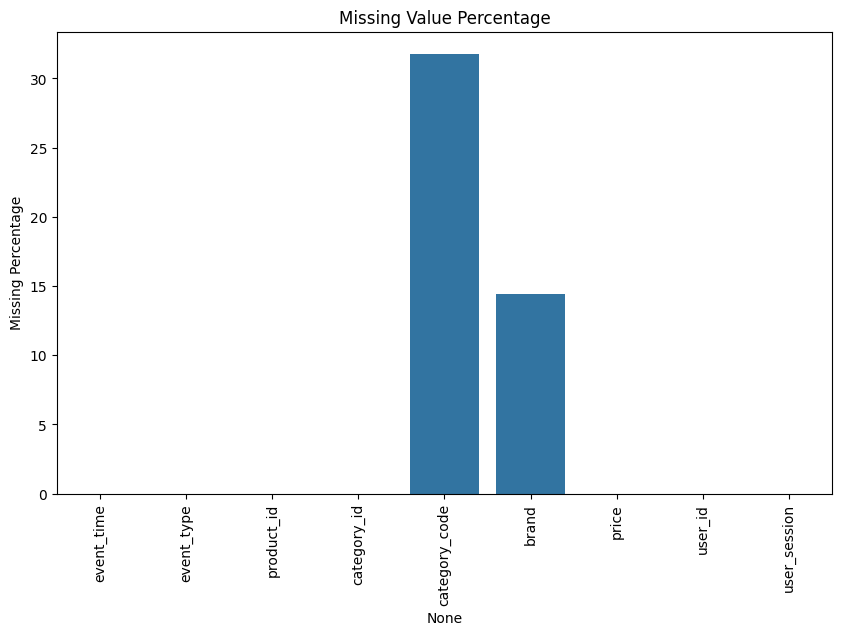

In [20]:
missing_values = df_muestra.isnull().sum()

missing_percentage = (df_muestra.isnull().sum() / len(df_muestra)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

print(missing_df.sort_values(by='Missing Percentage', ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_df.index,
    y=missing_df['Missing Percentage']
)
plt.xticks(rotation=90)
plt.title("Missing Value Percentage")
plt.show()

# Qué pregunta vamos a responder?

# Hipótesis?

hola muchachos vamos melos
